In [1]:

#Import necessary libraries
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import MultiStepLR
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random



In [2]:
if __name__ == '__main__'
    torch.manual_seed(42) #for code reproducibility
    
    device='cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device:{device}")

Using device:cuda


In [3]:
# Perform tranformations
train_transform=transforms.Compose([
    transforms.Pad(4), 
    transforms.RandomCrop(32), 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),   # CIFAR-10 mean 
        (0.2470, 0.2435, 0.2616))  # CIFAR-10 std
])

test_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),   # CIFAR-10 mean 
        (0.2470, 0.2435, 0.2616))  # CIFAR-10 std
])

In [4]:

# Load datasets
train_dataset=torchvision.datasets.CIFAR10(root='/kaggle/working/',train=True,download=True,transform=train_transform)
test_dataset=torchvision.datasets.CIFAR10(root='/kaggle/working/',train=False,download=True,transform=test_transform)



Files already downloaded and verified
Files already downloaded and verified


In [5]:
train_loader=DataLoader(train_dataset,batch_size=128,num_workers=4,pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=128,num_workers=4,pin_memory=True)

In [6]:
def conv3x3(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)
import torch.nn.functional as F


class LambdaLayer(nn.Module):
    def __init__(self, func):
        super().__init__()
        self.func = func
    def forward(self, x):
        return self.func(x)

class BasicBlock(nn.Module):
    def __init__(self,in_channel,out_channel,stride):
        super().__init__()
        self.in_channel=in_channel
        self.out_channel=out_channel
        self.stride=stride
        
        self.conv1=nn.Conv2d(in_channel,out_channel,kernel_size=3,padding=1,stride=stride,bias=False)
        self.bn1=nn.BatchNorm2d(out_channel)
        self.conv2=nn.Conv2d(out_channel,out_channel,kernel_size=3,padding=1,stride=1,bias=False)
        self.bn2=nn.BatchNorm2d(out_channel)
        self.relu=nn.ReLU(inplace=True)

    def forward(self,x):
        x1=self.relu(self.bn1(self.conv1(x)))
        x2=self.bn2(self.conv2(x1))

        # Shortcut connection to macth dimensions
        if self.stride!=1 or self.in_channel!=self.out_channel:
            shortcut=x[:,:,::self.stride,::self.stride]
            pad=(0,0,0,0,0,self.out_channel-self.in_channel)
            shortcut=F.pad(shortcut,pad,mode='constant',value=0)
        else:
            shortcut=x
        return self.relu(x2+shortcut)


class BasicBlockNoSkip(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()

        self.conv1 = conv3x3(in_planes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)

        self.conv2 = conv3x3(planes, planes, 1)
        self.bn2 = nn.BatchNorm2d(planes)

        # No shortcut

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = F.relu(out)   # <-- no residual addition
        return out


In [7]:
class ResNet(nn.Module):
    def __init__(self,num_classes=10,n=9):
        super().__init__()
        self.n=n

        #First conv layer
        self.conv1=nn.Conv2d(3,16,kernel_size=3,stride=1,padding=1,bias=False)
        self.bn=nn.BatchNorm2d(16)
        self.relu=nn.ReLU(inplace=True)
        
        #3 Stages of Residual Blocks
        self.stage1=self._make_layers(16,16,num_blocks=self.n,stride=1)
        self.stage2=self._make_layers(16,32,num_blocks=self.n,stride=2)
        self.stage3=self._make_layers(32,64,num_blocks=self.n,stride=2)

        #Remaining layers for Classification
        self.pool=nn.AdaptiveAvgPool2d(1)
        self.fc=nn.Linear(64,num_classes)

        # Weight initialization 
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layers(self,in_channel,out_channel,num_blocks,stride):
        layers=[]
        #First block(for downsampling)
        layers.append(BasicBlockNoSkip(in_channel,out_channel,stride)) # Change to BasicBlock to use standard resnet with skip
        #Remaining
        for _ in range(1,num_blocks):
            layers.append(BasicBlockNoSkip(out_channel,out_channel,stride=1)) # Change to BasicBlock to use standard resnet with skip
        return nn.Sequential(*layers)

    def forward(self,x):
        out=self.relu(self.bn(self.conv1(x)))
        out=self.stage1(out)
        out=self.stage2(out)
        out=self.stage3(out)
        out=self.pool(out)
        out=torch.flatten(out,1)
        out=self.fc(out)
        return out
        

In [8]:

model=ResNet(num_classes=10,n=9).to(device) #Here we will use n=9 for 56 layer ResNet
#print(model) 



In [9]:
criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,          # typical starting LR for ResNet on CIFAR-10
    momentum=0.9,    # Changing momentum to match Li et al to reproduce-like Figure 1(a)
    nesterov=True,
    weight_decay=5e-4
)

# divide lr by 10 at epochs corresponding to 32k and 48k iterations
epoch_32k = int(32000 / len(train_loader))
epoch_48k = int(48000 / len(train_loader))


# NOTE: The schduler below is for the learning rate set up for original ResNet paper
#scheduler = torch.optim.lr_scheduler.MultiStepLR(
#    optimizer,
#    milestones=[epoch_32k, epoch_48k],
#    gamma=0.1
#)

#NOTE:  The schduler below is for the learning rate set up for Li et al (Figure 1(a))
scheduler = MultiStepLR(
    optimizer,
    milestones=[150, 225, 275],
    gamma=0.1
)


In [10]:

if __name__ == '__main__'
    # epochs=180 # Total training iterations in paper is 64k, which is ~164 epochs. We will train for 180.
    epochs =300 # For Li et. al
    train_losses=[]
    train_accuracies=[]
    val_accuracies=[]
    
    for epoch in range(epochs):
        model.train()
        total_loss=0.0
        correct = 0
        total = 0
    
        for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
    
                optimizer.zero_grad()
                output=model(images)
                loss=criterion(output,labels)
                loss.backward()
                optimizer.step()
                #scheduler.step()
    
                total_loss+=loss.item()
                _,predicted=torch.max(output,1)
                total+=output.size(0)
                correct+=(predicted==labels).sum().item()
            
        avg_loss = total_loss / len(train_loader)
        train_acc=correct/total
        
        model.eval()
        correct_val=0
        total_val=0
    
        #evaluate
        with torch.no_grad():
            for images,labels in test_loader:
                images,labels=images.to(device),labels.to(device)
                output=model(images)
                _,predicted=torch.max(output,1)
                total_val+=labels.shape[0]
                correct_val+=(predicted==labels).sum().item()
    
            val_acc=correct_val/total_val
    
        # Store metrics for plotting
        train_losses.append(avg_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        scheduler.step() 
    
        
        #Print every 10th epoch
        if (epoch+1)%10==0:
            print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} Train Acc: {train_acc:.4f} Val Acc: {val_acc:.4f}")


Epoch [10/180] Loss: 0.6603 Train Acc: 0.7709 Val Acc: 0.7251
Epoch [20/180] Loss: 0.4013 Train Acc: 0.8592 Val Acc: 0.7987
Epoch [30/180] Loss: 0.2879 Train Acc: 0.8984 Val Acc: 0.8182
Epoch [40/180] Loss: 0.2149 Train Acc: 0.9235 Val Acc: 0.8435
Epoch [50/180] Loss: 0.1654 Train Acc: 0.9406 Val Acc: 0.8592
Epoch [60/180] Loss: 0.1313 Train Acc: 0.9530 Val Acc: 0.8389
Epoch [70/180] Loss: 0.1062 Train Acc: 0.9621 Val Acc: 0.8407
Epoch [80/180] Loss: 0.0853 Train Acc: 0.9697 Val Acc: 0.8657
Epoch [90/180] Loss: 0.0227 Train Acc: 0.9936 Val Acc: 0.8912
Epoch [100/180] Loss: 0.0170 Train Acc: 0.9957 Val Acc: 0.8910
Epoch [110/180] Loss: 0.0140 Train Acc: 0.9962 Val Acc: 0.8909
Epoch [120/180] Loss: 0.0118 Train Acc: 0.9974 Val Acc: 0.8905
Epoch [130/180] Loss: 0.0104 Train Acc: 0.9978 Val Acc: 0.8919
Epoch [140/180] Loss: 0.0093 Train Acc: 0.9979 Val Acc: 0.8906
Epoch [150/180] Loss: 0.0099 Train Acc: 0.9977 Val Acc: 0.8910
Epoch [160/180] Loss: 0.0102 Train Acc: 0.9978 Val Acc: 0.8914
E

In [11]:
# Define filename (saves in current directory)
if __name__ == '__main__'
    model_path = 'sgdmomentum_resnet56_noskip_cifar10_like_fig1a_Li_et_al.pth'
    
    # Save the model
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epochs": epochs,
    }, model_path)

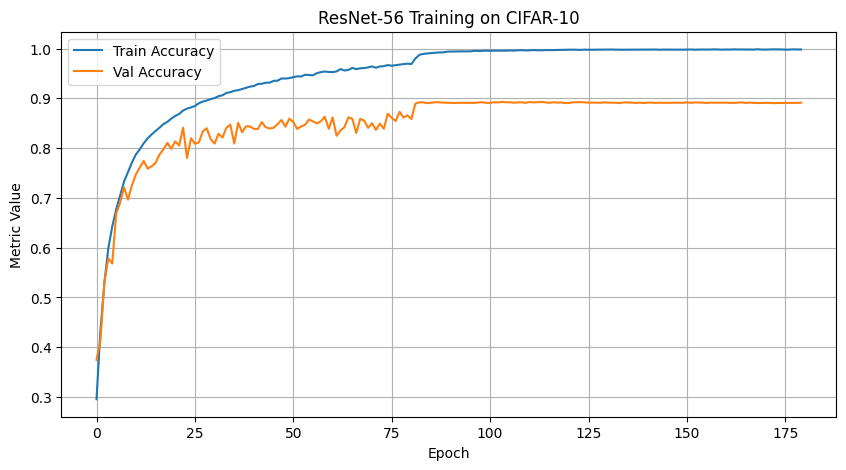

In [12]:
if __name__ == '__main__'
    plt.figure(figsize=(10,5))
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.title('ResNet-56 Training on CIFAR-10')
    plt.legend()
    plt.grid(True)
    plt.show()

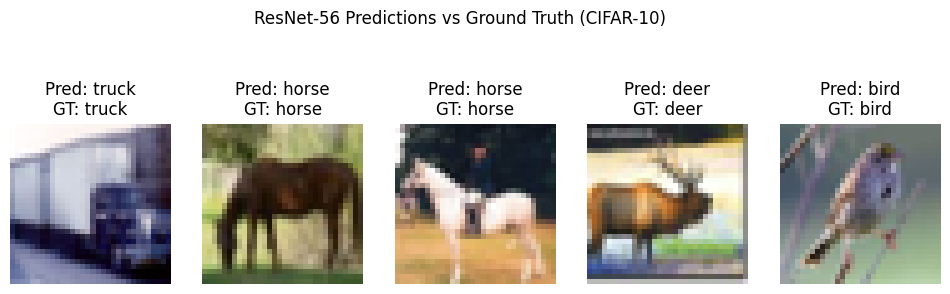

In [13]:
#Visualize the results
if __name__ == "__main__":

    classes = test_dataset.classes
    
    # Pick 5 random samples from the test set
    indices = random.sample(range(len(test_dataset)), 5)
    images, labels = zip(*[test_dataset[i] for i in indices])
    images_tensor = torch.stack(images).to(device)
    labels_tensor = torch.tensor(labels).to(device)
    
    # Get predictions
    model.eval()
    with torch.no_grad():
        outputs = model(images_tensor)
        _, preds = torch.max(outputs, 1)
    
    # Unnormalize for display
    def unnormalize(img):
        mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
        std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
        return img.cpu() * std + mean
    
    # Plot
    plt.figure(figsize=(12, 4))
    for i in range(5):
        img = unnormalize(images_tensor[i])
        npimg = np.transpose(img.numpy(), (1, 2, 0))
        plt.subplot(1, 5, i + 1)
        plt.imshow(np.clip(npimg, 0, 1))
        plt.title(f"Pred: {classes[preds[i]]}\nGT: {classes[labels[i]]}")
        plt.axis("off")
    plt.suptitle("ResNet-56 Predictions vs Ground Truth (CIFAR-10)")
    plt.show()